# Chapter 7: Reverse-Engineering the Pointer Transformer

Paired notebook for Chapter 7 of *Inductive Biases in Neural Networks*. It
regenerates every number the chapter asserts and the three figures the
chapter places, for **two distinct models in two frameworks** (Part III
design decision D).

| | sections 1-8 | section 9 (the flagship) |
|---|---|---|
| Model | from-scratch NumPy `BitTransformer` | introspectable PyTorch transformer |
| Size | 2 layers, 1 head, $d_{\text{model}}=32$ | 3 layers, 4 heads, $d_{\text{model}}=128$ |
| Task | $M=8$ pointer dereference | $M=32$ pointer dereference |
| Source | `examples/pointer_interp.py` | `examples/pytorch/pointer_interp_deep.py` |
| Here | **retrained** (2000 iters, seed 0) | **loaded** from `interp_deep_M32.pt` |

The two models solve the same *kind* of task at different scales. **Their
accuracies are not comparable across the framework boundary**, and the
chapter never compares them as numbers. What carries across is the method
and the lesson.

**torch is a notebook-only dependency** (declared in `pyproject.toml`),
needed solely for the $M=32$ probes: it loads the committed checkpoint (no
training) and runs the causal flip test, the per-layer ablations, and the
activation-patching causal trace. The $M=8$ cells are NumPy.

**Seeds.** The $M=8$ model is built and trained with `seed=0`; its held-out
test set uses `seed=1`. The $M=32$ checkpoint is fixed, so its numbers are
reproducible by construction; the probes that subsample use a fixed seed.

## Setup

Everything comes from `examples/`. The $M=8$ probes are in
`pointer_interp.py` (attention extraction, the address-partitioned
aggregate, the ablations); the model and data-generating process are in
`pointer_transformer.py` and `simple_pointer_dgp.py`. The $M=32$ probes are
in `pytorch/pointer_interp_deep.py` (the introspectable transformer, the
causal flip test, the per-layer ablations, the activation-patching causal
trace).

We add both `examples/` and `examples/pytorch/` to the path and import the
probe modules directly, so the listings in the chapter are exactly the code
that runs here.

In [1]:
import os
import sys
import math

import numpy as np
import matplotlib.pyplot as plt

# Locate examples/ in the parent scratchnn repo, two levels up from notebooks/.
HERE = os.getcwd()
REPO = os.path.abspath(os.path.join(HERE, "..", ".."))
EX = os.path.join(REPO, "examples")
EX_PT = os.path.join(EX, "pytorch")
for p in (EX, EX_PT):
    if p not in sys.path:
        sys.path.insert(0, p)

FIG_DIR = os.path.abspath(os.path.join(HERE, "..", "book", "figures"))
os.makedirs(FIG_DIR, exist_ok=True)
print("examples:", EX)
print("figures :", FIG_DIR)

examples: /home/spinoza/github/repos/scratchnn/examples
figures : /home/spinoza/github/repos/scratchnn/inductive-biases/book/figures


## Part 1 (M=8, NumPy): train the model the chapter dissects

A two-layer, one-head decoder transformer with $d_{\text{model}}=32$ and
$d_{\text{ff}}=64$, trained 2000 iterations with Adam at learning rate
$10^{-3}$, batch size 32, on 20{,}000 examples of the $M=8$, $A=3$ pointer
task. Each input is an 11-token sequence: 8 memory bits then 3 address bits,
MSB-first. The prediction at position 10 is the value at memory position
$a$, where $a$ is the integer decoded from the three address bits.

In [2]:
from simple_pointer_dgp import make_variant1
from pointer_experiments import train_transformer_on_examples, eval_transformer
from pointer_transformer import BitTransformer, count_params
import pointer_interp as pi

M8, A8, T8 = 8, 3, 11
SEED = 0

X_tr, Y_tr = make_variant1(20000, M=M8, A=A8, seed=SEED)
X_te, Y_te = make_variant1(2000, M=M8, A=A8, seed=SEED + 1)

model8 = BitTransformer(d_model=32, n_heads=1, d_ff=64, n_layers=2,
                        max_T=T8, seed=SEED)
print(f"parameters: {count_params(model8):,}")

train_transformer_on_examples(model8, X_tr, Y_tr, n_iters=2000, lr=1e-3,
                              batch_size=32, log_every=500, seed=SEED)
acc8, loss8 = eval_transformer(model8, X_te, Y_te)
print(f"M=8 test accuracy: {acc8:.4f}   loss: {loss8:.4f}")
assert acc8 >= 0.99, "M=8 model did not converge; interpretation would be on a non-solving model"


parameters: 17,282


      iter  500  loss 0.6583  (14s)


      iter 1000  loss 0.2791  (28s)


      iter 1500  loss 0.0001  (43s)


      iter 2000  loss 0.1343  (58s)


M=8 test accuracy: 1.0000   loss: 0.0000


### Section 3: layer 2 attends to the addressed memory position

For each address $a \in \{0,\dots,7\}$, average the layer-2 attention row
from the last input position (position 10) across the test examples with
that address. The weight that row places on memory cell $m_a$ is the
dereference signal. The probe is `pointer_interp.aggregate_last_row`, which
runs `model.attention_at(ctx, layer=1, head=0)` per example and groups the
last row by decoded address.

In [3]:
means8 = pi.aggregate_last_row(model8, X_te[:500], M=M8, A=A8)
print("address a | avg weight on m_a | avg on other memory")
on_ma = []
for a in sorted(means8):
    row = means8[a]
    w_ma = float(row[a])
    w_other = float(row[:M8].sum() - row[a])
    on_ma.append(w_ma)
    print(f"    {a}     |      {w_ma:.3f}       |     {w_other:.3f}")
print(f"\nrange of weight on m_a across addresses: {min(on_ma):.3f} to {max(on_ma):.3f}")


address a | avg weight on m_a | avg on other memory
    0     |      0.795       |     0.205
    1     |      0.706       |     0.294
    2     |      0.661       |     0.339
    3     |      0.708       |     0.252
    4     |      0.812       |     0.188
    5     |      0.710       |     0.286
    6     |      0.729       |     0.269
    7     |      0.676       |     0.315

range of weight on m_a across addresses: 0.661 to 0.812


### Section 4: layer 1 is the address aggregator

For four representative addresses, report where layer 1 at position 10 sends
its attention: the top-three attended positions with weights, and the total
mass on the address positions $\{8,9,10\}$ versus the memory positions
$\{0,\dots,7\}$. Position 8 (the MSB) should receive the most weight.

In [4]:
def layer1_report(model, ids, M=M8, A=A8):
    T = M + A
    attn_L1 = model.attention_at(ids[:T], layer=0, head=0)
    last = attn_L1[T - 1]
    top = list(np.argsort(last)[::-1][:3])
    top_w = [(int(p), round(float(last[p]), 2)) for p in top]
    on_addr = float(last[list(range(M, M + A))].sum())
    on_mem = float(last[:M].sum())
    return top_w, on_addr, on_mem

# pick the first test example for each of four addresses
picks, seen = [], set()
for ids in X_te:
    a = pi.address_value(ids, M=M8, A=A8)
    if a in {0, 4, 5, 7} and a not in seen:
        picks.append((a, ids[:T8].copy())); seen.add(a)
    if len(seen) == 4:
        break

print("address a | top-3 (pos, weight)                 | on addr | on memory")
for a, ids in sorted(picks):
    top_w, on_addr, on_mem = layer1_report(model8, ids)
    print(f"    {a}     | {str(top_w):37s} |  {on_addr:.3f}  |   {on_mem:.3f}")


address a | top-3 (pos, weight)                 | on addr | on memory
    0     | [(8, 0.49), (9, 0.41), (10, 0.05)]    |  0.956  |   0.044
    4     | [(8, 0.71), (9, 0.2), (7, 0.06)]      |  0.935  |   0.065
    5     | [(8, 0.73), (9, 0.19), (10, 0.06)]    |  0.986  |   0.014
    7     | [(8, 0.51), (9, 0.41), (10, 0.04)]    |  0.965  |   0.035


### Section 5: causal confirmation by ablation

Correlational evidence (layer 1 attends to address bits, layer 2 attends to
the addressed cell) is consistent with the circuit hypothesis but does not
prove the layers are load-bearing. Replace one layer's attention pattern
with the uniform-on-causal-prefix distribution and rerun the rest of the
forward pass: this removes the layer's content-addressable behavior while
keeping its value and feed-forward machinery intact. The shuffle ablation
permutes the three address bits, which leaves the bit *set* unchanged but
destroys *which bit is which*.

The probes are `pointer_interp.ablation_zero_layer_attn` and
`ablation_shuffle_address`.

In [5]:
base = eval_transformer(model8, X_te, Y_te)[0]
z1 = pi.ablation_zero_layer_attn(model8, X_te[:500], Y_te[:500], layer_idx=0, M=M8, A=A8)
z2 = pi.ablation_zero_layer_attn(model8, X_te[:500], Y_te[:500], layer_idx=1, M=M8, A=A8)
sh = pi.ablation_shuffle_address(model8, X_te[:500], Y_te[:500], M=M8, A=A8, seed=SEED + 7)

print("intervention                  | test accuracy")
print(f"baseline (no intervention)    |     {base:.3f}")
print(f"layer 1 attention -> uniform  |     {z1:.3f}")
print(f"layer 2 attention -> uniform  |     {z2:.3f}")
print(f"shuffle the 3 address bits     |     {sh:.3f}")


intervention                  | test accuracy
baseline (no intervention)    |     1.000
layer 1 attention -> uniform  |     0.658
layer 2 attention -> uniform  |     0.636
shuffle the 3 address bits     |     0.776


### Cache the M=8 attention maps for the contrast figure

For the legible half of `fig:attn-contrast`, cache the layer-2 attention
matrix for one clean example (address $a=4$). The bottom row is position
10's query; its mass concentrates on column 4 ($m_4$).

In [6]:
a_demo = 4
ctx_demo = None
for ids in X_te:
    if pi.address_value(ids, M=M8, A=A8) == a_demo:
        ctx_demo = ids[:T8].copy(); break
attn8_L2 = model8.attention_at(ctx_demo, layer=1, head=0)   # (T, T)
print("M=8 layer-2 attention, last-row argmax:",
      int(np.argmax(attn8_L2[T8 - 1])),
      "weight", round(float(attn8_L2[T8 - 1].max()), 3))

M=8 layer-2 attention, last-row argmax: 4 weight 0.973


## Part 2 (M=32, PyTorch): load the checkpoint and run the causal probes

Now the flagship. The same task at $M=32$ needs a third layer. The model
here is an explicit three-layer transformer (4 heads, $d_{\text{model}}=128$,
learned positional encoding) with attention written out by hand so every
pattern is readable. We **load the committed checkpoint** (no training): it
solves $M=32$ to 0.9965 and its numbers are fixed.

**Implementation-realization aside (ties to the Chapter 6 PE-scale lesson).**
This model only trains if its query/key/value projections use Xavier-uniform
initialization. With PyTorch's default `Linear` init (Kaiming-uniform,
$a=\sqrt 5$) the projections are mis-scaled, the phase transition is pushed
past a usable budget, and the circuit never forms. Right architecture, right
depth, wrong init scale on one set of tensors. The checkpoint was trained
with the Xavier init the model class sets in `_init_projections`.

In [7]:
import torch
import pointer_interp_deep as deep

M32 = 32
A32 = max(3, (M32 - 1).bit_length())   # 5
T32 = M32 + A32                        # 37
print(f"M={M32}, A={A32}, T={T32}")

Xd_te, Yd_te = make_variant1(2000, M=M32, A=A32, seed=1)

torch.manual_seed(0)
model32 = deep.IntrospectableTransformer(
    d_model=128, n_heads=4, n_layers=3, d_ff=256, max_T=T32)
print(f"parameters: {deep.count_params(model32):,}")

assert os.path.exists(deep.CKPT), f"checkpoint missing: {deep.CKPT}"
model32.load_state_dict(torch.load(deep.CKPT, weights_only=True))
model32.eval()
acc32 = deep.evaluate(model32, Xd_te, Yd_te)
print(f"M=32 test accuracy (from the fixed checkpoint): {acc32:.4f}")

M=32, A=5, T=37
parameters: 402,946


M=32 test accuracy (from the fixed checkpoint): 0.9965


### Section 9.1: causally, it is a perfect pointer

Start with the question that does not depend on reading any attention map:
does the model compute exactly $m_a$? Take a correctly handled example, flip
the bit at the addressed cell $m_a$, and check whether the prediction
follows the new value. Then flip a bit at a random *non*-addressed cell and
check whether the prediction is disturbed. The probe is
`pointer_interp_deep.causal_flip_test`.

In [8]:
tracks, other = deep.causal_flip_test(model32, Xd_te, M32, A32,
                                      n_examples=600, seed=0)
print("intervention                       | prediction follows?")
print(f"flip the addressed cell m_a        |   {tracks:.3f}")
print(f"flip a random non-addressed cell   |   {other:.3f}")
print("\nFlipping m_a flips the answer; flipping any other cell does almost")
print("nothing. Behaviorally, the 3-layer model is a perfect pointer.")

intervention                       | prediction follows?
flip the addressed cell m_a        |   0.995
flip a random non-addressed cell   |   0.005

Flipping m_a flips the answer; flipping any other cell does almost
nothing. Behaviorally, the 3-layer model is a perfect pointer.


### Section 9.2: mechanically, the clean circuit is gone

Now read the attention, hoping to find an aggregation layer and a single
lookup head spiking on $m_a$. First, where the last-position query sends its
attention per layer (averaged over the test set), split into weight on the
address positions, on the memory positions, and on the addressed cell
$m_a$.

In [9]:
stats = deep.analyze(model32, Xd_te, M32, A32, n_examples=400)
print("layer | on address | on memory | on m_a")
for li in range(stats["n_layers"]):
    print(f"  {li+1}   |   {stats['on_addr'][li]:.3f}    |   "
          f"{stats['on_mem'][li]:.3f}   | {stats['on_correct'][li]:.3f}")
print("\nLayers 1-2 attend mostly to the address positions (a two-stage")
print("aggregation); the dereference weight on m_a is largest in layer 3,")
print("but layer 2 does almost no dereferencing (the first refuted hypothesis).")

layer | on address | on memory | on m_a
  1   |   0.512    |   0.488   | 0.016
  2   |   0.667    |   0.333   | 0.047
  3   |   0.578    |   0.422   | 0.080

Layers 1-2 attend mostly to the address positions (a two-stage
aggregation); the dereference weight on m_a is largest in layer 3,
but layer 2 does almost no dereferencing (the first refuted hypothesis).


Now layer 3 head by head: the weight each head puts on the addressed
cell. Head 0 is the only candidate lookup head, and even it is weak.

In [10]:
print("layer 3 head |  h0   |  h1   |  h2   |  h3")
h = stats["head_on_correct"][2]
print(f"weight on m_a | {h[0]:.3f} | {h[1]:.3f} | {h[2]:.3f} | {h[3]:.3f}")
print(f"(uniform over {M32} cells = {1.0/M32:.3f})")

# clean single-head coverage and the layer-3 ensemble
covered, union, H = deep.head_coverage(model32, Xd_te, M32, A32, layers=(1, 2))
ens = deep.layer3_ensemble_on_correct(model32, Xd_te, M32, A32)
n_ens = sum(1 for v in ens.values() if v > 0.5)
print(f"\nsingle-head clean coverage (weight on m_a > 0.5): {len(union)} of {2**A32} addresses")
print(f"layer-3 ensemble weight on m_a > 0.5: {n_ens} of {2**A32}  (mean {np.mean(list(ens.values())):.3f})")
print("=> the lookup heads do NOT partition the address space (the second refuted hypothesis)")

layer 3 head |  h0   |  h1   |  h2   |  h3
weight on m_a | 0.198 | 0.089 | 0.031 | 0.002
(uniform over 32 cells = 0.031)



single-head clean coverage (weight on m_a > 0.5): 10 of 32 addresses
layer-3 ensemble weight on m_a > 0.5: 8 of 32  (mean 0.291)
=> the lookup heads do NOT partition the address space (the second refuted hypothesis)


The per-layer ablations confirm the load-bearing structure without
identifying a clean lookup: layers 1 and 3 are essential, layer 2 is
auxiliary. The probe is `pointer_interp_deep.ablate_layer_uniform`.

In [11]:
base32 = deep.evaluate(model32, Xd_te[:400], None)
print("intervention                      | accuracy")
print(f"baseline (first 400)              |  {base32:.4f}")
for li in range(3):
    a = deep.ablate_layer_uniform(model32, Xd_te, M32, A32, li, n_examples=400)
    print(f"layer {li+1} attention -> uniform        |  {a:.4f}")

intervention                      | accuracy
baseline (first 400)              |  0.9975


layer 1 attention -> uniform        |  0.5400


layer 2 attention -> uniform        |  0.7625


layer 3 attention -> uniform        |  0.6000


### The lookup head tracks only a sparse subset of addresses (`fig:lookup-by-address`)

Plot head L3H0's weight on $m_a$ as a function of the address. It
dereferences cleanly (weight 0.8 to 1.0) for a sparse handful of addresses
and does essentially nothing for the rest. This is `fig:lookup-by-address`.

lookup head = layer 3, head 0  (avg weight on m_a = 0.198)


addresses this head dereferences cleanly (>0.5): [5, 6, 10, 13, 17, 19]


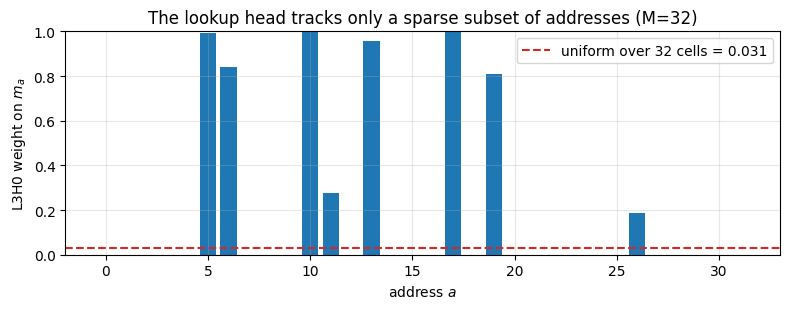

wrote /home/spinoza/github/repos/scratchnn/inductive-biases/book/figures/ch07-lookup-by-address.pdf


In [12]:
li_lh, hi_lh, w_lh = deep.find_lookup_head(stats)
print(f"lookup head = layer {li_lh+1}, head {hi_lh}  (avg weight on m_a = {w_lh:.3f})")
on_correct = deep.lookup_head_profile(model32, Xd_te, M32, A32, li_lh, hi_lh)
clean = sorted(a for a, w in on_correct.items() if w > 0.5)
print("addresses this head dereferences cleanly (>0.5):", clean)

addrs = sorted(on_correct)
weights = [on_correct[a] for a in addrs]
uniform = 1.0 / M32
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(addrs, weights, color="#1f77b4")
ax.axhline(uniform, color="#d62728", ls="--",
           label=f"uniform over {M32} cells = {uniform:.3f}")
ax.set_xlabel("address $a$")
ax.set_ylabel(f"L{li_lh+1}H{hi_lh} weight on $m_a$")
ax.set_title("The lookup head tracks only a sparse subset of addresses (M=32)")
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
out = os.path.join(FIG_DIR, "ch07-lookup-by-address.pdf")
fig.savefig(out, bbox_inches="tight")
plt.show()
print("wrote", out)

### Section 9.4: causal tracing recovers the clean mechanism (`fig:causal-trace`)

The flip test told us $m_a$ is read; it did not tell us *how the value gets
from cell $a$ to the readout*. Trace it. For each minimal pair (clean input
vs the same input with $m_a$ flipped), patch the clean residual into the
corrupted run at one (layer, position) at a time and measure how much the
readout recovers the clean answer:

$$\text{recovery} = \frac{\Delta_{\text{patched}} - \Delta_{\text{corrupt}}}
{\Delta_{\text{clean}} - \Delta_{\text{corrupt}}}, \quad
\Delta = \text{logit}[\text{answer}] - \text{logit}[\text{other}].$$

Recovery near 1 marks a (layer, position) that *carries* $m_a$; near 0 marks
one that does not. Averaged over 100 minimal pairs, grouped by position
class. The probe is `pointer_interp_deep.causal_trace`. This is the
flagship figure.

In [13]:
recovery, classes, nL, used = deep.causal_trace(model32, Xd_te, M32, A32,
                                                n_examples=100)
print(f"(averaged over {used} minimal pairs)")
nice = {"addressed": "addressed m_a", "other_mem": "other memory",
        "addr_bits": "address bits", "readout": "readout (36)"}
rowlabels = ["embedding"] + [f"after layer {L}" for L in range(1, nL + 1)]
print(f"{'residual point':<16}" + "".join(f"{nice[c]:>16}" for c in classes))
for L in range(nL + 1):
    print(f"{rowlabels[L]:<16}" + "".join(f"{recovery[(L, c)]:>16.3f}" for c in classes))

# the flagship figure
deep.plot_causal_trace(recovery, classes, nL,
                       os.path.join(FIG_DIR, "ch07-causal-trace.pdf"))
plt.show() if False else None
print("\nwrote", os.path.join(FIG_DIR, "ch07-causal-trace.pdf"))

(averaged over 100 minimal pairs)
residual point     addressed m_a    other memory    address bits    readout (36)
embedding                  1.000           0.000           0.000           0.000
after layer 1              0.328           0.003           0.108           0.105
after layer 2              0.185           0.002           0.097           0.297
after layer 3              0.000           0.000           0.000           1.000



wrote /home/spinoza/github/repos/scratchnn/inductive-biases/book/figures/ch07-causal-trace.pdf


Read it top to bottom. At the embedding, all the recovery is at the
addressed cell (1.000): a sanity check the method passes exactly. Across the
three layers the addressed cell drains to 0.000 while the readout position
fills to 1.000, with the address bits a partial intermediate conduit and
every other memory cell flat at zero. $m_a$ is *transported* from cell $a$
to the readout over the three layers. The mechanism is clean; it lived in
the residual-stream flow, not in the attention weights.

### The contrast figure (`fig:attn-contrast`): legible M=8 beside illegible M=32

Put the two models side by side. Left: the $M=8$ layer-2 attention for one
example, a sharp spike on $m_4$. Right: the $M=32$ last-position attention
averaged across the test set for layer 3, diffuse across memory. The single
increment in problem size did not make the mechanism messier in any deep
sense (the causal trace just showed it is a clean pointer); it made the
mechanism invisible to the *weak* instrument.

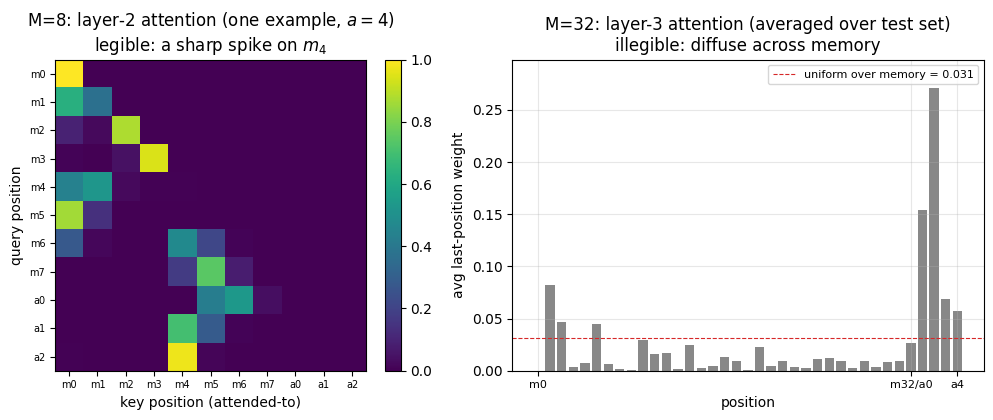

wrote /home/spinoza/github/repos/scratchnn/inductive-biases/book/figures/ch07-attn-contrast.pdf


In [14]:
# left panel: the cached M=8 layer-2 attention matrix
# right panel: the M=32 layer-3 last-position attention averaged over the test set
@torch.no_grad()
def avg_last_row_layer(model, X, M, A, layer_idx, n=400):
    T = M + A
    acc = np.zeros(T)
    c = 0
    for ids in X[:n]:
        ctx = ids[:T]
        rows = deep.per_layer_last_row(model, ctx)   # list over layers, each (T,)
        acc += rows[layer_idx]
        c += 1
    return acc / c

row32_L3 = avg_last_row_layer(model32, Xd_te, M32, A32, layer_idx=2, n=400)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

# M=8 legible
ax = axes[0]
im = ax.imshow(attn8_L2, cmap="viridis", vmin=0, vmax=1.0, aspect="equal")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
labels8 = [f"m{i}" for i in range(M8)] + [f"a{i}" for i in range(A8)]
ax.set_xticks(range(T8)); ax.set_yticks(range(T8))
ax.set_xticklabels(labels8, fontsize=7); ax.set_yticklabels(labels8, fontsize=7)
ax.set_xlabel("key position (attended-to)"); ax.set_ylabel("query position")
ax.set_title("M=8: layer-2 attention (one example, $a=4$)\nlegible: a sharp spike on $m_4$")

# M=32 illegible
ax = axes[1]
colors = ["#888"] * T32
ax.bar(range(T32), row32_L3, color=colors)
ax.axhline(1.0 / M32, color="#d62728", ls="--", lw=0.8,
           label=f"uniform over memory = {1.0/M32:.3f}")
ax.set_ylim(0, max(0.2, float(row32_L3.max()) * 1.1))
ax.set_xticks([0, M32, T32 - 1])
ax.set_xticklabels(["m0", f"m{M32}/a0", f"a{A32-1}"], fontsize=8)
ax.set_xlabel("position")
ax.set_ylabel("avg last-position weight")
ax.set_title("M=32: layer-3 attention (averaged over test set)\nillegible: diffuse across memory")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.tight_layout()
out = os.path.join(FIG_DIR, "ch07-attn-contrast.pdf")
fig.savefig(out, bbox_inches="tight")
plt.show()
print("wrote", out)

## Results: every number the chapter asserts

A single cell that prints the regenerated numbers the prose uses, so a
reader can diff the chapter against this notebook. The $M=8$ numbers
regenerate from the seed-0 retrain; the $M=32$ numbers come from the fixed
checkpoint and are reproducible by construction.

In [15]:
print("=== M=8 (NumPy, retrained seed 0) ===")
print(f"test accuracy ............................ {acc8:.4f}")
print(f"layer-2 weight on m_a, range over addrs .. {min(on_ma):.3f} to {max(on_ma):.3f}")
print(f"ablation baseline ........................ {base:.3f}")
print(f"layer-1 attn -> uniform .................. {z1:.3f}")
print(f"layer-2 attn -> uniform .................. {z2:.3f}")
print(f"shuffle address bits ..................... {sh:.3f}")
print()
print("=== M=32 (PyTorch, fixed checkpoint) ===")
print(f"test accuracy ............................ {acc32:.4f}")
print(f"causal flip: tracks m_a .................. {tracks:.3f}")
print(f"causal flip: flip-other changes .......... {other:.3f}")
print(f"layer-2 dereference weight on m_a ........ {stats['on_correct'][1]:.3f}   (refuted H1)")
print(f"L3H0 weight on m_a ....................... {stats['head_on_correct'][2,0]:.3f}")
print(f"single-head clean coverage ............... {len(union)} of {2**A32}   (refuted H2)")
print(f"per-layer ablation (L1/L2/L3) ............ "
      f"{deep.ablate_layer_uniform(model32, Xd_te, M32, A32, 0, 400):.3f} / "
      f"{deep.ablate_layer_uniform(model32, Xd_te, M32, A32, 1, 400):.3f} / "
      f"{deep.ablate_layer_uniform(model32, Xd_te, M32, A32, 2, 400):.3f}")
print(f"causal trace: embedding -> addressed m_a . {recovery[(0,'addressed')]:.3f}")
print(f"causal trace: after L3 -> readout ........ {recovery[(nL,'readout')]:.3f}")
print()
print("figures written to book/figures/:")
for f in ("ch07-attn-contrast.pdf", "ch07-lookup-by-address.pdf", "ch07-causal-trace.pdf"):
    p = os.path.join(FIG_DIR, f)
    print(f"  {f}: {'ok' if os.path.exists(p) else 'MISSING'}")

=== M=8 (NumPy, retrained seed 0) ===
test accuracy ............................ 1.0000
layer-2 weight on m_a, range over addrs .. 0.661 to 0.812
ablation baseline ........................ 1.000
layer-1 attn -> uniform .................. 0.658
layer-2 attn -> uniform .................. 0.636
shuffle address bits ..................... 0.776

=== M=32 (PyTorch, fixed checkpoint) ===
test accuracy ............................ 0.9965
causal flip: tracks m_a .................. 0.995
causal flip: flip-other changes .......... 0.005
layer-2 dereference weight on m_a ........ 0.047   (refuted H1)
L3H0 weight on m_a ....................... 0.198
single-head clean coverage ............... 10 of 32   (refuted H2)


per-layer ablation (L1/L2/L3) ............ 0.540 / 0.762 / 0.600
causal trace: embedding -> addressed m_a . 1.000
causal trace: after L3 -> readout ........ 1.000

figures written to book/figures/:
  ch07-attn-contrast.pdf: ok
  ch07-lookup-by-address.pdf: ok
  ch07-causal-trace.pdf: ok
